
# FFT Analysis of a 1D Time Series

This notebook demonstrates how to analyze a one-dimensional time series using the Fast Fourier Transform (FFT). It includes the mathematical background, a synthetic example, reusable functions, dominant-frequency detection, amplitude/phase spectra, power spectral density, and a simple frequency-domain filter.

You can run the notebook as-is, then replace the synthetic signal with your own data.



## 1. Mathematical background

Suppose we observe a real-valued discrete time series

$$
x[n] = x(t_n), \qquad n = 0,1,\ldots,N-1,
$$

sampled at a constant sampling interval

$$
\Delta t = \frac{1}{f_s},
$$

where $f_s$ is the sampling frequency in samples per second. The total record length is

$$
T = N \Delta t.
$$

The Discrete Fourier Transform (DFT) represents the signal as a sum of complex sinusoidal components:

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-i 2\pi kn/N}, \qquad k=0,1,\ldots,N-1.
$$

The inverse DFT reconstructs the signal:

$$
x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k] e^{i 2\pi kn/N}.
$$

The FFT is an efficient algorithm for computing the DFT. Instead of requiring $O(N^2)$ operations, it typically requires $O(N\log N)$ operations.



## 2. Frequency bins and interpretation

Each DFT coefficient $X[k]$ corresponds to a frequency bin

$$
f_k = \frac{k}{N\Delta t} = \frac{k f_s}{N}.
$$

For real-valued signals, the FFT spectrum is conjugate symmetric, so it is common to use the one-sided FFT containing only nonnegative frequencies:

$$
f \in \left[0, \frac{f_s}{2}\right],
$$

where $f_s/2$ is the Nyquist frequency.

The frequency resolution is

$$
\Delta f = \frac{f_s}{N} = \frac{1}{T}.
$$

A longer recording improves frequency resolution. Increasing the sampling rate increases the maximum resolvable frequency, but does not by itself improve frequency resolution unless the total duration also increases.


In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True



## 3. Create an example signal

The example signal below combines two sinusoidal components, a slow trend, and random noise:

$$
x(t) = 1.5\sin(2\pi f_1 t) + 0.8\sin(2\pi f_2 t + \phi) + \text{trend} + \text{noise}.
$$

For your own data, replace `x` with your measured 1D time series and set `fs` to the correct sampling frequency.


In [13]:

# Sampling parameters
fs = 200.0          # sampling frequency in Hz
duration = 10.0    # seconds
N = int(fs * duration)
t = np.arange(N) / fs

# Signal components
f1 = 8.0            # Hz
f2 = 35.0           # Hz
phi = np.pi / 5     # phase shift

rng = np.random.default_rng(42)
x = (
    1.5 * np.sin(2 * np.pi * f1 * t)
    + 0.8 * np.sin(2 * np.pi * f2 * t + phi)
    + 0.0 * t
    + 0.5 * rng.normal(size=N)
)

print(f"Number of samples N = {N}")
print(f"Sampling frequency fs = {fs} Hz")
print(f"Sampling interval dt = {1/fs:.6f} s")
print(f"Duration T = {N/fs:.3f} s")
print(f"Frequency resolution df = {fs/N:.3f} Hz")
print(f"Nyquist frequency = {fs/2:.3f} Hz")


Number of samples N = 2000
Sampling frequency fs = 200.0 Hz
Sampling interval dt = 0.005000 s
Duration T = 10.000 s
Frequency resolution df = 0.100 Hz
Nyquist frequency = 100.000 Hz


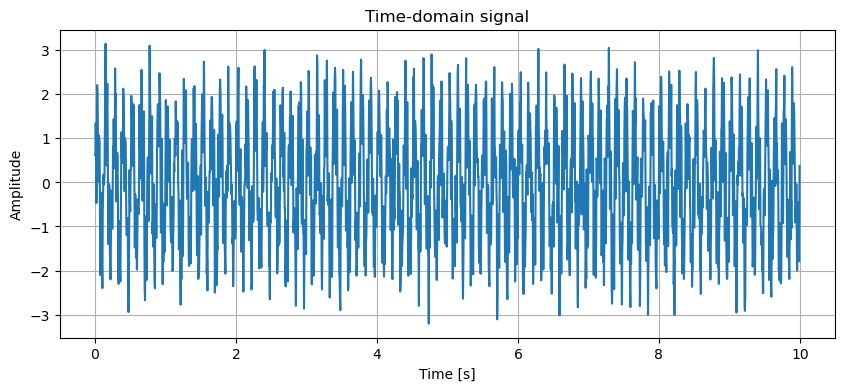

In [14]:

plt.figure()
plt.plot(t, x)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Time-domain signal")
plt.show()



## 4. Preprocessing before FFT

FFT analysis assumes the finite observed signal is one period of a periodic signal. If the endpoints do not match smoothly, spectral leakage can occur.

Useful preprocessing steps:

1. **Remove the mean** to eliminate a large DC component at 0 Hz.
2. **Remove a trend** if low-frequency drift is not part of the phenomenon of interest.
3. **Apply a window** to reduce leakage.

A window changes amplitude scaling, so the amplitude spectrum below corrects for the window coherent gain:

$$
G_c = \frac{1}{N}\sum_{n=0}^{N-1} w[n].
$$


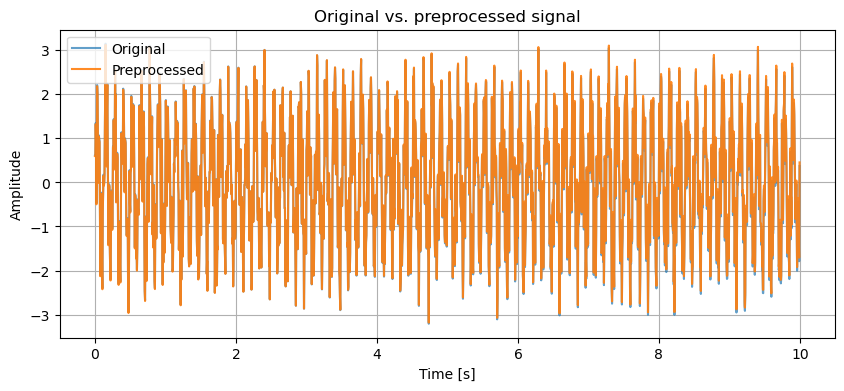

In [15]:

def detrend_linear(y: np.ndarray) -> np.ndarray:
    # Remove a best-fit linear trend from a 1D signal.
    n = np.arange(len(y))
    coeffs = np.polyfit(n, y, deg=1)
    trend = np.polyval(coeffs, n)
    return y - trend

# Choose preprocessing options
remove_mean = True
remove_linear_trend = True
use_window = True

x_proc = x.copy()
if remove_linear_trend:
    x_proc = detrend_linear(x_proc)
elif remove_mean:
    x_proc = x_proc - np.mean(x_proc)

if remove_mean and not remove_linear_trend:
    x_proc = x_proc - np.mean(x_proc)

window = np.hanning(N) if use_window else np.ones(N)
x_win = x_proc * window
coherent_gain = np.mean(window)

plt.figure()
plt.plot(t, x, label="Original", alpha=0.7)
plt.plot(t, x_proc, label="Preprocessed", alpha=0.9)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Original vs. preprocessed signal")
plt.legend()
plt.show()



## 5. One-sided FFT amplitude spectrum

For a real-valued signal, use `np.fft.rfft` to compute the nonnegative-frequency FFT. The corresponding frequency bins are computed with `np.fft.rfftfreq`.

A common one-sided amplitude estimate is

$$
A[k] = \frac{2}{N G_c}|X[k]|,
$$

for non-DC and non-Nyquist bins. The DC component and Nyquist component, when present, should not be doubled.


In [16]:

def one_sided_fft(y: np.ndarray, fs: float, window: str | None = "hann"):
    # Compute one-sided FFT amplitude, phase, and power spectral density.
    y = np.asarray(y)
    N = len(y)

    if window == "hann":
        w = np.hanning(N)
    elif window is None:
        w = np.ones(N)
    else:
        raise ValueError("Supported windows: 'hann' or None")

    y_windowed = y * w
    X = np.fft.rfft(y_windowed)
    freqs = np.fft.rfftfreq(N, d=1 / fs)

    coherent_gain = np.mean(w)
    amplitude = np.abs(X) / (N * coherent_gain)
    amplitude[1:-1] *= 2

    # Phase is meaningful mainly where amplitude is sufficiently large.
    phase = np.angle(X)

    # Window power normalization for a one-sided periodogram-like PSD.
    # Units are signal_units^2 / Hz.
    window_power = np.sum(w**2)
    psd = (np.abs(X) ** 2) / (fs * window_power)
    psd[1:-1] *= 2

    return {
        "freqs": freqs,
        "fft": X,
        "amplitude": amplitude,
        "phase": phase,
        "psd": psd,
        "window": w,
    }

result = one_sided_fft(x_proc, fs, window="hann")
freqs = result["freqs"]
amplitude = result["amplitude"]
phase = result["phase"]
psd = result["psd"]


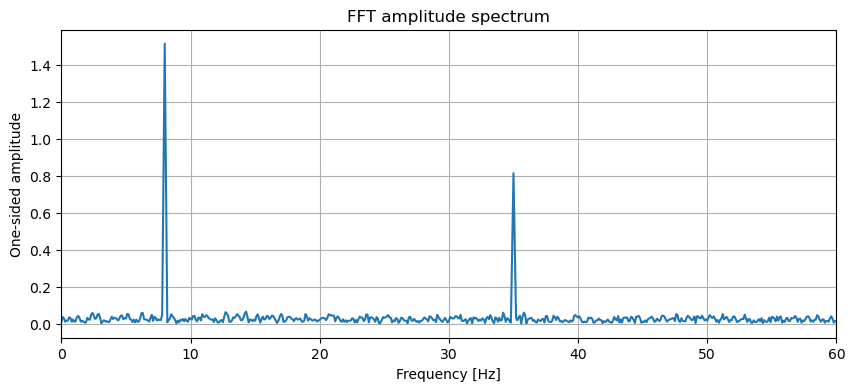

In [17]:

plt.figure()
plt.plot(freqs, amplitude)
plt.xlim(0, 60)
plt.xlabel("Frequency [Hz]")
plt.ylabel("One-sided amplitude")
plt.title("FFT amplitude spectrum")
plt.show()


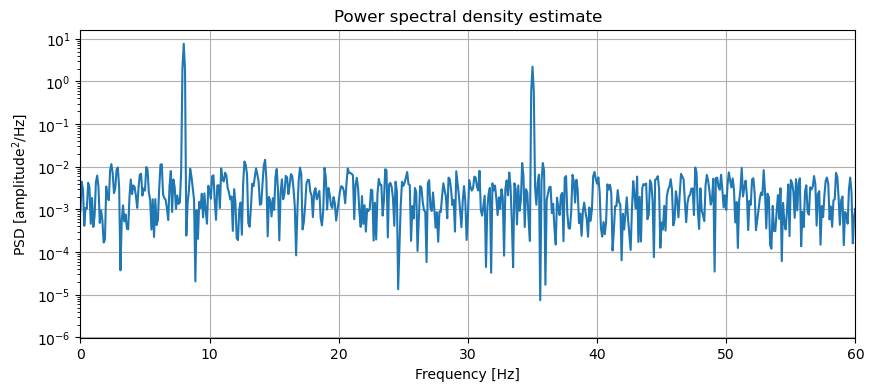

In [18]:

plt.figure()
plt.semilogy(freqs, psd)
plt.xlim(0, 60)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [amplitude$^2$/Hz]")
plt.title("Power spectral density estimate")
plt.show()



## 6. Dominant frequency detection

The largest amplitude peaks, excluding the DC component, correspond to dominant oscillatory components in the signal. Because noise and leakage can produce nearby bins, peak picking is often done after restricting to a frequency band of interest.


In [19]:

def dominant_frequencies(freqs, amplitude, n_peaks=5, f_min=0.0, f_max=None):
    # Return the largest amplitude frequency bins in a chosen frequency range.
    if f_max is None:
        f_max = freqs[-1]

    mask = (freqs >= f_min) & (freqs <= f_max)
    idx = np.where(mask)[0]

    # Exclude DC unless explicitly requested by f_min == 0 and it is desired.
    idx = idx[freqs[idx] > 0]

    top_idx = idx[np.argsort(amplitude[idx])[-n_peaks:]][::-1]
    return pd.DataFrame({
        "frequency_Hz": freqs[top_idx],
        "amplitude": amplitude[top_idx],
        "phase_rad": phase[top_idx],
        "psd": psd[top_idx],
    })

top = dominant_frequencies(freqs, amplitude, n_peaks=8, f_min=1, f_max=80)
top


,frequency_Hz,amplitude,phase_rad,psd
0,8.0,1.515944,-1.559199,7.656455
1,35.0,0.815196,-0.941684,2.214043
2,7.9,0.777154,1.552026,2.012223
3,8.1,0.741190,1.573175,1.830292
4,35.1,0.424853,2.138994,0.601365
5,34.9,0.411741,2.231309,0.564820
6,14.3,0.066137,-1.743889,0.014573
7,12.7,0.063188,1.449456,0.013302



## 7. Phase spectrum

The phase of a component is

$$
\phi[k] = \arg(X[k]).
$$

Phase is most interpretable at frequencies where the amplitude is large. At frequencies dominated by noise, phase is usually not meaningful.


In [ ]:

# Plot phase only where amplitude is above a threshold to avoid noisy clutter.
threshold = 0.10 * np.max(amplitude)
mask = amplitude > threshold

plt.figure()
plt.stem(freqs[mask], phase[mask], basefmt=" ")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [rad]")
plt.title("Phase at high-amplitude frequencies")
plt.show()



## 8. Frequency-domain filtering and reconstruction

The inverse FFT can reconstruct a filtered version of the signal by zeroing out unwanted frequency bins.

For example, a band-pass filter keeps frequencies in a selected interval:

$$
X_{\mathrm{filtered}}[k] =
\begin{cases}
X[k], & f_{\min} \le f_k \le f_{\max}, \\
0, & \text{otherwise}.
\end{cases}
$$

Then the filtered time-domain signal is obtained with the inverse real FFT:

$$
x_{\mathrm{filtered}}[n] = \operatorname{irfft}(X_{\mathrm{filtered}}).
$$

This is a simple ideal frequency-domain filter. In production analyses, use care: sharp cutoffs can create ringing in the time domain.


In [ ]:

def fft_bandpass_filter(y: np.ndarray, fs: float, f_low: float, f_high: float):
    # Simple ideal band-pass filter using FFT bin masking.
    y = np.asarray(y)
    N = len(y)
    Y = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(N, d=1 / fs)

    keep = (freqs >= f_low) & (freqs <= f_high)
    Y_filtered = np.zeros_like(Y)
    Y_filtered[keep] = Y[keep]

    y_filtered = np.fft.irfft(Y_filtered, n=N)
    return y_filtered, freqs, keep

# Keep the two known sinusoidal bands approximately.
y_filtered, _, _ = fft_bandpass_filter(x_proc, fs, f_low=5, f_high=40)

plt.figure()
plt.plot(t, x_proc, label="Preprocessed signal", alpha=0.5)
plt.plot(t, y_filtered, label="FFT band-pass filtered", linewidth=2)
plt.xlim(0, 2)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Time-domain reconstruction after FFT band-pass filtering")
plt.legend()
plt.show()



## 9. Using your own time series

Replace the synthetic `x` and `fs` values with your data. Your time samples should be evenly spaced.

Example for a CSV file with columns `time` and `value`:

```python
df = pd.read_csv("my_timeseries.csv")
t = df["time"].to_numpy()
x = df["value"].to_numpy()

# Estimate sampling frequency from the median time step
dt = np.median(np.diff(t))
fs = 1 / dt
```

If your time series is not evenly sampled, resample or interpolate onto a uniform grid before applying the FFT.


In [ ]:

# Template for your own data:
# df = pd.read_csv("my_timeseries.csv")
# t = df["time"].to_numpy()
# x = df["value"].to_numpy()
# dt = np.median(np.diff(t))
# fs = 1 / dt
#
# x_proc = detrend_linear(x - np.mean(x))
# result = one_sided_fft(x_proc, fs, window="hann")
# freqs = result["freqs"]
# amplitude = result["amplitude"]
# psd = result["psd"]
#
# plt.figure()
# plt.plot(freqs, amplitude)
# plt.xlabel("Frequency [Hz]")
# plt.ylabel("One-sided amplitude")
# plt.title("FFT amplitude spectrum")
# plt.show()



## 10. Practical checklist

- Confirm the sampling frequency `fs` is correct.
- Make sure the samples are evenly spaced.
- Remove mean and trends when they are not scientifically meaningful.
- Use a window when the signal does not contain an integer number of cycles in the observation window.
- Interpret frequencies only up to the Nyquist frequency $f_s/2$.
- Remember that frequency resolution is $\Delta f = f_s/N = 1/T$.
- For noisy signals, consider averaging methods such as Welch's method.
